#### Generate Simluation

In [ ]:
import numpy as np
import scanpy as sc
import seaborn as sns
import sys

sys.path.append('../simulator')
from hiererchical_simulator import get_data_and_visualize

import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [ ]:
data_df, adata = get_data_and_visualize(tree_id=100)

sc.pp.normalize_total(adata, target_sum=1e4)

#### Compute CME

In [ ]:
sys.path.append('../CME')
from CME_func import CME, CME_correction

In [ ]:
sns.heatmap(np.log(adata.X+1))

In [ ]:
import importlib
import sys
importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction

In [ ]:
X = adata.X.T.astype(np.float32)

X_normed = X / X.sum(axis=1)[None,:].T * 1e4
#print(X_normed.sum(axis=1))
#print(X_normed)

cme = CME(X_normed, normalize=True, cuda=True)
sns.heatmap(cme, cmap='viridis')

##### Manual CME and Correction

In [ ]:
null_CME = []

X_shuffled = X_normed.astype(dtype=np.float32)

iteration = 10

for i in range(iteration):
    for row in X_shuffled:
        np.random.shuffle(row)

    X_shuffled = X_shuffled / X_shuffled.sum(axis=1)[None,:].T * 1e4

    cme_shuffled = CME(X_shuffled, normalize=True)
    sns.heatmap(cme_shuffled, cmap='viridis')
    null_CME.append(cme_shuffled)

null_CME_ary = np.array(null_CME)

import pickle

filename = "null_CME_"+str(iteration)+".pkl"
with open(filename, "wb") as file:
        pickle.dump(null_CME_ary, file, protocol=pickle.HIGHEST_PROTOCOL)


In [ ]:
plt.scatter(adata.X.T[54], adata.X.T[182])

In [ ]:
plt.scatter(X_normed[54], X_normed[182])

In [ ]:
plt.scatter(X_shuffled[54], X_shuffled[182])

In [ ]:
filename = "null_CME_10.pkl"
with open(filename, "rb") as file:
        loaded_data = pickle.load(file)

cme_rank = np.zeros(cme.shape)

for i in range(cme.shape[0]):
    for j in range(cme.shape[1]):
        cme_rank[i, j] = np.sum(loaded_data[:, i, j] > cme[i, j])

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

sns.heatmap(cme, cmap='viridis', ax=axes[0])
sns.heatmap(cme_rank, cmap='viridis', ax=axes[1])

plt.tight_layout()
plt.show()

##### CME correction

In [ ]:
cme_corrected = CME_correction(X_normed, cme, cuda=True, iterations=50)

In [ ]:
cme_corrected = cme.copy()
cme_corrected[cme_rank >= 9] = 0
cme_corrected[(cme_rank >= 2) &(cme_rank <=8)] = 0.5

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

#sns.heatmap(cme_rank, cmap='viridis', ax=axes[0])
sns.heatmap(cme, cmap='viridis', ax=axes[0])
sns.heatmap(cme_corrected, cmap='viridis', ax=axes[1])

plt.tight_layout()
plt.show()

##### No Normalize CME

In [ ]:
cme = CME(adata.X.T, normalize=False)
sns.heatmap(cme, cmap='viridis')

#### CM data analyze

In [ ]:
import sys
sys.path.append('../CME')
from CME_func import CME, CME_correction
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scanpy as sc, anndata as ad

import importlib
import sys
importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction

def compute_cme_and_plot(X, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    cme = CME(X, normalize=True, cuda=cuda)
    cme_corrected = CME_correction(X, cme, tp_cutoff=tp_cutoff, fp_cutoff=fp_cutoff, cuda=cuda)
    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

    sns.heatmap(cme, cmap='viridis', ax=axes[0])
    sns.heatmap(cme_corrected, cmap='viridis', ax=axes[1])

    plt.tight_layout()
    plt.show()


def get_selected_genes(adata, gene_set, convert=False):

    if convert:
        gene_index = adata.var.index[pd.Index(adata.var["feature_name"]).get_indexer(gene_set)]
    else:
        gene_index = gene_set

    select_data = adata[:, gene_index]
    return select_data


def cme_process_data(file_path, gene_set, convert=False, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    adata = ad.read_h5ad(file_path)
    sc.pp.normalize_total(adata, target_sum=1e4)
    genes_to_keep = adata.X.sum(axis=0) > 100
    filtered_data = adata[:, genes_to_keep]

    select_data, _ = get_selected_genes(filtered_data, gene_set, convert)
    X = select_data.X.T.toarray()
    
    compute_cme_and_plot(X, tp_cutoff, fp_cutoff, cuda=cuda)

In [ ]:
gene_set = ["NPPA", "NPPB", "SPOCK1", "SLC6A6", "GLP1R", "RAPGEF4", "GUCY1A1", "CLIC6", "EDIL3", "GNAQ", "HECW2"]
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

cme_process_data(file_path, gene_set, True, tp_cutoff=0.7, fp_cutoff=0.1, cuda=True)

In [ ]:
file_path = '../CM_data/sedman_res_one_new2.h5ad'

cme_process_data(file_path, gene_set, tp_cutoff=0.7, fp_cutoff=0.1, cuda=True)

#### Find all candidate genes who are mutually exclusive against the CM genes.

In [ ]:
import importlib
import sys
sys.path.append('../CME')

#importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def get_selected_genes(adata, gene_set):
    gene_idx = adata.var.index.get_indexer(gene_set)
    gene_idx = gene_idx.astype(np.int32)


def compute_and_correct_cme(adata, gene_set, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    gene_idx = get_selected_genes(adata, gene_set)
    X = adata.X.T.toarray()
    
    cme = CME(X, normalize=True, feature_indices=gene_idx, cuda=cuda)
    print("finished CME")
    cme_corrected = CME_correction(X, cme, feature_indices=gene_idx, tp_cutoff=tp_cutoff, fp_cutoff=fp_cutoff, cuda=cuda)
    print("finished CME correction")
    return cme, cme_corrected


def plot_cme_and_correction(file_path, gene_set, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    adata = ad.read_h5ad(file_path)
    sc.pp.normalize_total(adata, target_sum=1e4)
    
    genes_to_keep = adata.X.sum(axis=0) > 100
    filtered_data = adata[:, genes_to_keep]

    cme, corrected_cme = compute_and_correct_cme(
        filtered_data, gene_set, tp_cutoff, fp_cutoff, cuda
    )

    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

    sns.heatmap(cme, cmap='viridis', ax=axes[0])
    sns.heatmap(corrected_cme, cmap='viridis', ax=axes[1])

    plt.tight_layout()
    plt.show()


In [ ]:
# All the files.
file_path = '../CM_data/sedman_res_one_new2.h5ad'
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

In [ ]:
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

gene_set = ["NPPA", "NPPB", "SPOCK1", "SLC6A6"]

plot_cme_and_correction(file_path, gene_set, cuda=True)

In [ ]:
# Reindex the adata
adata.var.set_index("feature_name", inplace=True)
adata.var

#### Test Normalize

In [ ]:
X=adata.X.T

In [ ]:
np.median(X[55][np.nonzero(X[55])])

In [ ]:
median_ary = np.apply_along_axis(lambda v: np.median(v[np.nonzero(v)]), 1, X)

In [ ]:
X_normed = X / median_ary[:, None]

In [ ]:
 X.sum(axis=1)[:,None].shape

# GPU New Codebase test

Parsing xml tree file...
Generating alpha matrix...


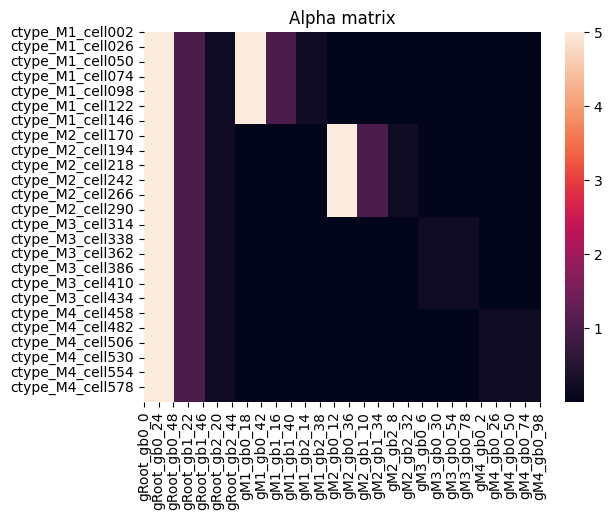

Sampling p's from Dirichlet distribution...
Sampling cell total UMIs from logNormal distribution...
M1 10 3.0
M2 10 3.0
M3 10 3.0
M4 10 3.0
Sampling cells from multinomial distribution...


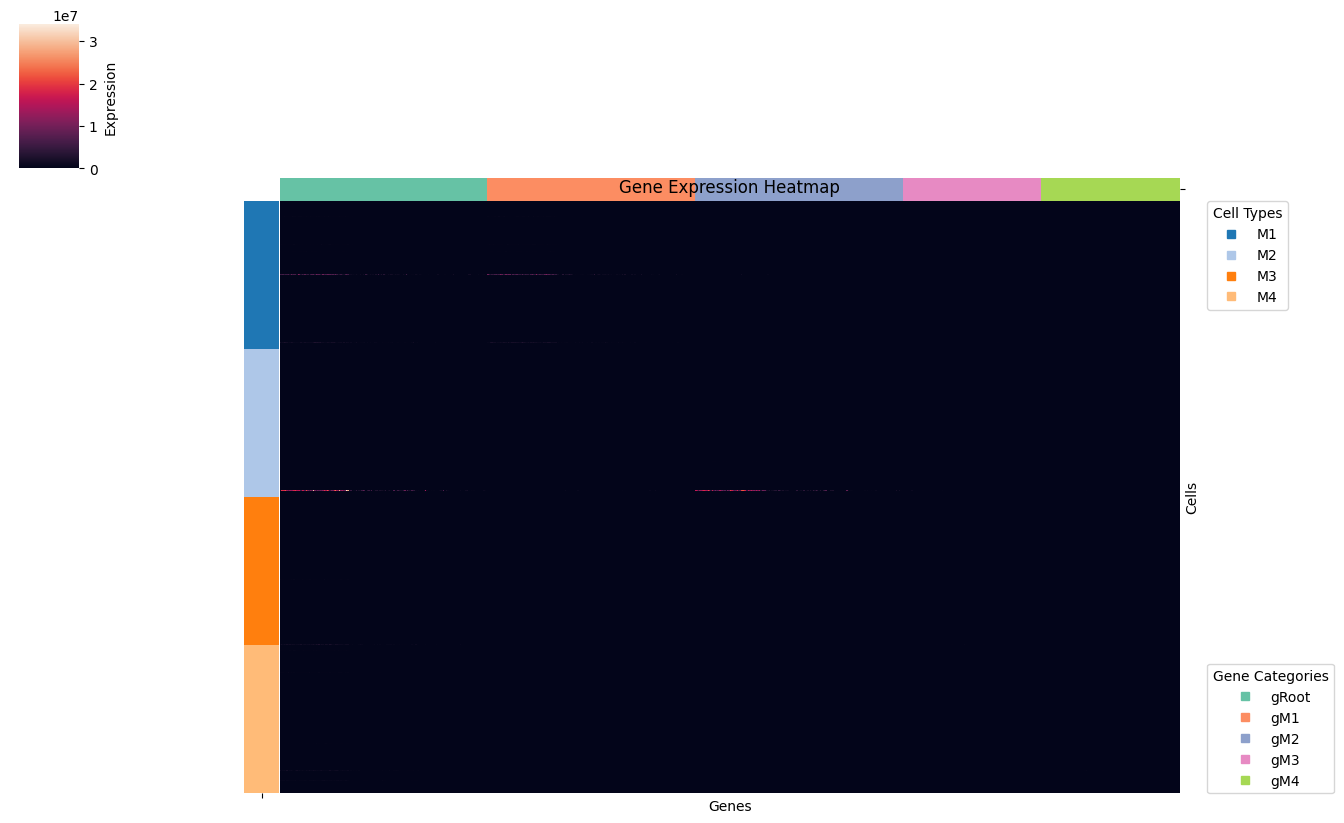

Saving anndata to: ../sim_data/adata/adata_100.h5ad


In [2]:
import numpy as np
import scanpy as sc
import seaborn as sns
import sys

sys.path.append('../simulator')
from hiererchical_simulator import get_data_and_visualize

import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

data_df, adata = get_data_and_visualize(tree_id=100)

sc.pp.normalize_total(adata, target_sum=1e4)

In [3]:
import importlib
sys.path.append('../CME')
#from CME_GPU_new import CME_cuda, CME_corrected
#importlib.reload(sys.modules[CME_cuda.__module__])
from CME_CPU import CME_cpu, CME_corrected
#importlib.reload(sys.modules[CME_cpu.__module__])


/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [4]:
X = adata.X.astype(np.float32)
X_normed = X / X.sum(axis=1)[None,:].T * 1e4
X_normed = X_normed.T

In [5]:
X_normed

array([[ 84.71097  ,  39.85286  ,  55.41032  , ...,  69.834526 ,
         89.3263   , 271.50803  ],
       [ 47.871616 ,  49.049667 ,  11.650375 , ..., 151.81418  ,
         85.12187  , 297.67746  ],
       [149.61974  , 165.54262  , 113.66219  , ..., 129.04205  ,
        169.58575  , 191.36409  ],
       ...,
       [  0.       ,   3.0656042,  24.43737  , ...,   6.072567 ,
          3.178006 ,   1.6355904],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.4145225,  67.05921  ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
         39.05065  ,   0.       ]], dtype=float32)

In [6]:
#cme = CME_cpu(X_normed, normalize=True, feature_indices=np.array([1,2]))
cme = CME_corrected(X_normed)
# cme = CME_cuda(X_normed, normalize=True, feature_indices=np.array([1,2]))

[[[ 0.0000000e+00  3.5101330e-01  3.4352016e-01 ...  8.2344908e-01
    8.0191934e-01  7.5500470e-01]
  [ 3.5101330e-01  0.0000000e+00  3.4108740e-01 ...  8.2787448e-01
    8.0878317e-01  7.5018871e-01]
  [ 3.4352016e-01  3.4108740e-01  5.9604645e-08 ...  8.2172579e-01
    8.1512922e-01  7.9017276e-01]
  ...
  [ 8.2344908e-01  8.2787448e-01  8.2172579e-01 ... -1.1920929e-07
    9.4309068e-01  9.8217916e-01]
  [ 8.0191934e-01  8.0878317e-01  8.1512922e-01 ...  9.4309068e-01
    0.0000000e+00  9.5002282e-01]
  [ 7.5500470e-01  7.5018871e-01  7.9017276e-01 ...  9.8217916e-01
    9.5002282e-01  0.0000000e+00]]

 [[ 0.0000000e+00  3.5281283e-01  3.4074491e-01 ...  8.6039370e-01
    8.2717335e-01  7.7808827e-01]
  [ 3.5281283e-01  0.0000000e+00  3.4439534e-01 ...  8.1652957e-01
    8.1060570e-01  7.7879083e-01]
  [ 3.4074491e-01  3.4439534e-01  0.0000000e+00 ...  8.3790445e-01
    7.9133391e-01  7.7641082e-01]
  ...
  [ 8.6039370e-01  8.1652957e-01  8.3790445e-01 ...  0.0000000e+00
    9.3495

<Axes: >

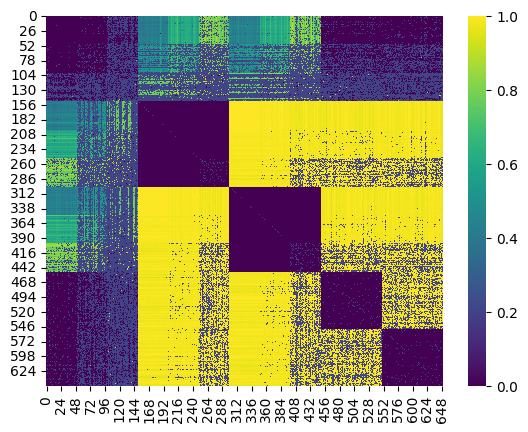

In [9]:
import seaborn as sns

sns.heatmap(cme[0], cmap='viridis')

## CUPY Playground

In [22]:
import cupy as cp

print("CuPy statically linked CUDA version:", cp.cuda.runtime.runtimeGetVersion())
print("System CUDA runtime version:", cp.cuda.get_local_runtime_version())
print("Compute capability of device 0:", cp.cuda.Device(0).compute_capability)

# This should now work without error
x = cp.arange(100, dtype=cp.float32)
print("Successfully created a CuPy array.")

CuPy statically linked CUDA version: 12090
System CUDA runtime version: 12080
Compute capability of device 0: 120
Successfully created a CuPy array.


In [ ]:
X_gpu = cp.asarray(X_normed)

In [ ]:
min_ary = cp.minimum(X_gpu[0,:], X_gpu[1,:])

In [ ]:
sum_ary = cp.sum(X_gpu, axis=1, dtype=cp.float32)

In [ ]:
sum_ary[0]

In [ ]:
cp.sum(min_ary) / sum_ary[0]

In [23]:
arr = cp.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])

In [24]:
random_matrix = cp.random.rand(*arr.shape)

In [25]:
random_matrix

array([[0.05949591, 0.53481015, 0.23261167],
       [0.81840188, 0.80269472, 0.75644782],
       [0.95481165, 0.24431052, 0.20728821]])

In [28]:
shuffled_idx = random_matrix.argsort(axis=1)
shuffled_idx

array([[0, 2, 1],
       [2, 1, 0],
       [2, 1, 0]])

In [29]:
cp.take_along_axis(arr, shuffled_idx, axis=1)


array([[1, 3, 2],
       [6, 5, 4],
       [9, 8, 7]])

In [32]:
X, Y, Z = 5, 3, 4

# Create sample 3D array A
# A[0,:,:] has smaller values, A[4,:,:] has larger values
A = np.arange(X * Y * Z).reshape(X, Y, Z)

# Create sample 2D array B
B = np.random.randint(low=20, high=40, size=(Y, Z))

print("Shape of A:", A.shape)
print("Shape of B:", B.shape)
print("\nSample of A:\n", A)
print("\nSample of B:\n", B)

# The elegant one-liner:
count_matrix = np.sum(A > B, axis=0)
print(count_matrix)

Shape of A: (5, 3, 4)
Shape of B: (3, 4)

Sample of A:
 [[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]

 [[24 25 26 27]
  [28 29 30 31]
  [32 33 34 35]]

 [[36 37 38 39]
  [40 41 42 43]
  [44 45 46 47]]

 [[48 49 50 51]
  [52 53 54 55]
  [56 57 58 59]]]

Sample of B:
 [[24 30 23 33]
 [37 37 27 29]
 [22 38 29 31]]
[[2 2 3 2]
 [2 2 3 3]
 [3 2 3 3]]
